In [1]:
import torch
import math
import sys, os

In [2]:
from train.unitary_single_qubit_gate.universal_single_qubit_SCORE import *
from visualize.util import *
from model.universal_model import UniversalQOCTransformer, Pipeline
from model.GRAPE_model import GRAPE

/Users/minkishim/anaconda3/envs/composite_pulse_demo/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Calculating fidelities for: transformer_len100



Calculating fidelities for: transformer_len400



Calculating fidelities for: GRAPE


GRAPE α:   0%|          | 0/100 [00:00<?, ?it/s]/Users/minkishim/Desktop/MIT/2025-26/Thesis/High-Fidelity Quantum Control/universal_quantum_optimal_control/model/GRAPE_model.py:157: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Copy.cpp:307.)
  return score_sequence.to(rotation_vector.device, rotation_vector.dtype)  # (B, L, 2)


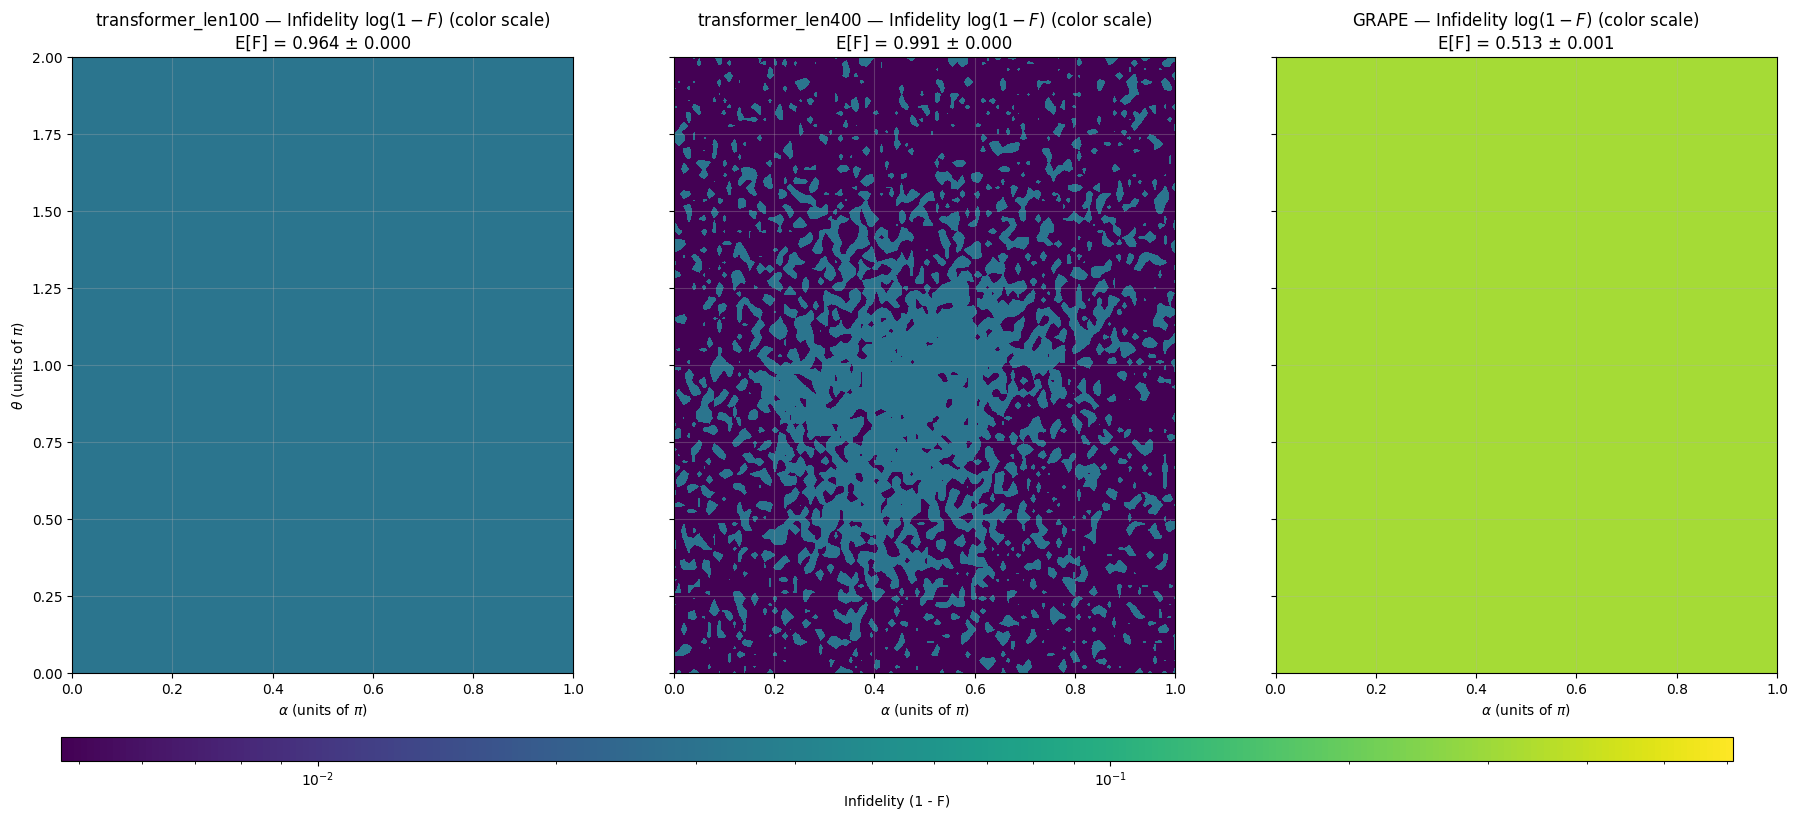

In [3]:
# --- Imports (add any you were already using) ---
import math, numpy as np, torch
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.cm as cm
import matplotlib.ticker as mticker
from scipy.linalg import expm  # if you still need Rx/Ry

# from your_module import Pipeline, UniversalQOCTransformer, GRAPE
# from your_module import get_ore_ple_error_distribution, batched_unitary_generator, fidelity

# ---------------------- Constants / Pauli ----------------------
_I2_CPU = torch.eye(2, dtype=torch.cfloat)
_SIGMA_X_CPU = torch.tensor([[0.0, 1.0], [1.0, 0.0]], dtype=torch.cfloat)
_SIGMA_Y_CPU = torch.tensor([[0.0, -1.0j], [1.0j, 0.0]], dtype=torch.cfloat)
_SIGMA_Z_CPU = torch.tensor([[1.0, 0.0], [0.0, -1.0]], dtype=torch.cfloat)
pauli = [_I2_CPU, _SIGMA_X_CPU, _SIGMA_Y_CPU, _SIGMA_Z_CPU]

def Rx(theta):
    return expm(-1j * _SIGMA_X_CPU * theta / 2)

def Ry(theta):
    return expm(-1j * _SIGMA_Y_CPU * theta / 2)

def _rotation_unitary(axis, theta) -> torch.Tensor:
    if isinstance(axis, (tuple, list)):
        axis = torch.tensor(axis, dtype=torch.float64)
    axis = axis / axis.norm()
    n_x, n_y, n_z = axis
    H = 0.5 * theta * (n_x * _SIGMA_X_CPU + n_y * _SIGMA_Y_CPU + n_z * _SIGMA_Z_CPU)
    return torch.matrix_exp(-1j * H)

def get_unitary(alpha, theta):
    H = math.cos(alpha) * _SIGMA_Z_CPU + math.sin(alpha) * _SIGMA_X_CPU
    return torch.linalg.matrix_exp(-1j * H * theta / 2)

def load_model_params(json_path):
    import json
    with open(json_path, "r") as f:
        return json.load(f)

def build_pipeline(kind: str):
    if kind == "100 length":
        name = "transformer_len100"
        path = "demo_universal/weight/length_100.pt"
        params = load_model_params("demo_universal/params/length_100.json")
        pipe = Pipeline(UniversalQOCTransformer(**params), weight_path=path, device="cpu")
    elif kind == "400 length":
        name = "transformer_len400"
        path = "demo_universal/weight/length_400.pt"
        params = load_model_params("demo_universal/params/length_400.json")
        pipe = Pipeline(UniversalQOCTransformer(**params), weight_path=path, device="cpu")
    elif kind == "GRAPE":
        name = "GRAPE"
        path = "demo_universal/weight/grape.pt"
        params = load_model_params("demo_universal/params/grape.json")
        pipe = GRAPE(**params)
        pipe.load_state_dict(torch.load(path, map_location="cpu"))
        pipe.eval()
    else:
        raise ValueError(f"Unknown model kind: {kind}")
    return name, pipe

def get_total_pulse(pipeline, axis, theta):
    n_x, n_y, n_z = axis
    inp = torch.tensor([n_x, n_y, n_z, theta], dtype=torch.float32).unsqueeze(0)
    return pipeline(inp).squeeze(0).detach()

def avg_fidelity(U_target, pulse, M=10000):
    errors_mc = get_ore_ple_error_distribution(M, 1, 0.05)
    U_target_plot = torch.stack([U_target]).repeat_interleave(M, dim=0)
    pulses_plot = torch.stack([pulse]).repeat_interleave(M, dim=0)
    U_out_plot = batched_unitary_generator(pulses_plot, errors_mc)
    F = fidelity(U_out_plot, U_target_plot, 1)
    return F.mean().item()

# ---------------------- Grid / runtime controls ----------------------
N_ALPHA = 100
N_THETA = 100
MC_SAMPLES = 1000

alpha_vals = torch.linspace(0, math.pi, N_ALPHA)
theta_vals = torch.linspace(0, 2*math.pi, N_THETA)

alpha_grid, theta_grid = torch.meshgrid(alpha_vals, theta_vals, indexing="ij")
alpha_np = (alpha_grid.detach().cpu().numpy()) / np.pi   # 0..1
theta_np = (theta_grid.detach().cpu().numpy()) / np.pi   # 0..2

# weights for your stats (kept)
weights = (theta_grid ** 2) * torch.sin(alpha_grid)
weights_np = weights.detach().cpu().numpy()

# ---------------------- Compute grids for each model ----------------------
models = ["100 length", "400 length", "GRAPE"]
results = []   # {name, F_np, I_np, weighted_avg, weighted_se}

for kind in models:
    name, pipe = build_pipeline(kind)
    print(f"\nCalculating fidelities for: {name}")
    F_grid = []
    for alpha in tqdm(alpha_vals, desc=f"{name} α", leave=False):
        for theta in theta_vals:
            U_t = get_unitary(float(alpha), float(theta))
            axis = (math.sin(float(alpha)), 0.0, math.cos(float(alpha)))
            pulse = get_total_pulse(pipe, axis, float(theta))
            F_grid.append(avg_fidelity(U_t, pulse, M=MC_SAMPLES))
    F_grid_tensor = torch.tensor(F_grid).reshape(N_ALPHA, N_THETA)
    F_np = F_grid_tensor.numpy()

    # raw infidelity
    I_np = 1.0 - F_np

    # weighted stats still reported on F
    weighted_avg = (F_np * weights_np).sum() / weights_np.sum()
    weighted_var = ((weights_np * (F_np - weighted_avg) ** 2).sum()) / weights_np.sum()
    N_eff = (weights_np.sum()) ** 2 / (weights_np ** 2).sum()
    weighted_se = float(np.sqrt(weighted_var) / np.sqrt(N_eff))

    results.append({
        "name": name,
        "F_np": F_np,
        "I_np": I_np,
        "weighted_avg": float(weighted_avg),
        "weighted_se": weighted_se
    })

# ---------------------- Shared log color scheme across panels ----------------------
# Clip zeros for LogNorm stability
EPS = 1e-12
for r in results:
    r["I_np"] = np.clip(r["I_np"], EPS, None)

I_min = min(r["I_np"].min() for r in results)
I_max = max(r["I_np"].max() for r in results)

# Optional clamp to a standard band (e.g., 1e-4..1e-1):
# I_min, I_max = 1e-4, 1e-1

log_norm = LogNorm(vmin=I_min, vmax=I_max)
cmap = "viridis"
levels = 100

# ---------------------- Plot: 1×3 row, shared colorbar ----------------------
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(22, 8), sharex=True, sharey=True)
if not isinstance(axes, (list, np.ndarray)):
    axes = [axes]

for ax, r in zip(axes, results):
    # NOTE: we pass raw infidelity and use LogNorm; this is equivalent to plotting log(1-F)
    cf = ax.contourf(alpha_np, theta_np, r["I_np"], levels=levels, cmap=cmap, norm=log_norm)
    ax.grid(True, alpha=0.3)
    ax.set_title(
        rf"{r['name']} — Infidelity $\log(1-F)$ (color scale)"
        + f"\nE[F] = {r['weighted_avg']:.3f} ± {r['weighted_se']:.3f}"
    )

axes[0].set_ylabel(r"$\theta$ (units of $\pi$)")
for ax in axes:
    ax.set_xlabel(r"$\alpha$ (units of $\pi$)")




# after plotting
sm = cm.ScalarMappable(norm=log_norm, cmap=cmap); sm.set_array([])

# [left, bottom, width, height] in figure coords
cax = fig.add_axes([0.12, 0.0, 0.76, 0.03])
cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
cbar.set_label("Infidelity (1 - F)")
# cbar.formatter = mticker.FuncFormatter(lambda x, pos: f"{x:g}")
cbar.update_ticks()

plt.show()



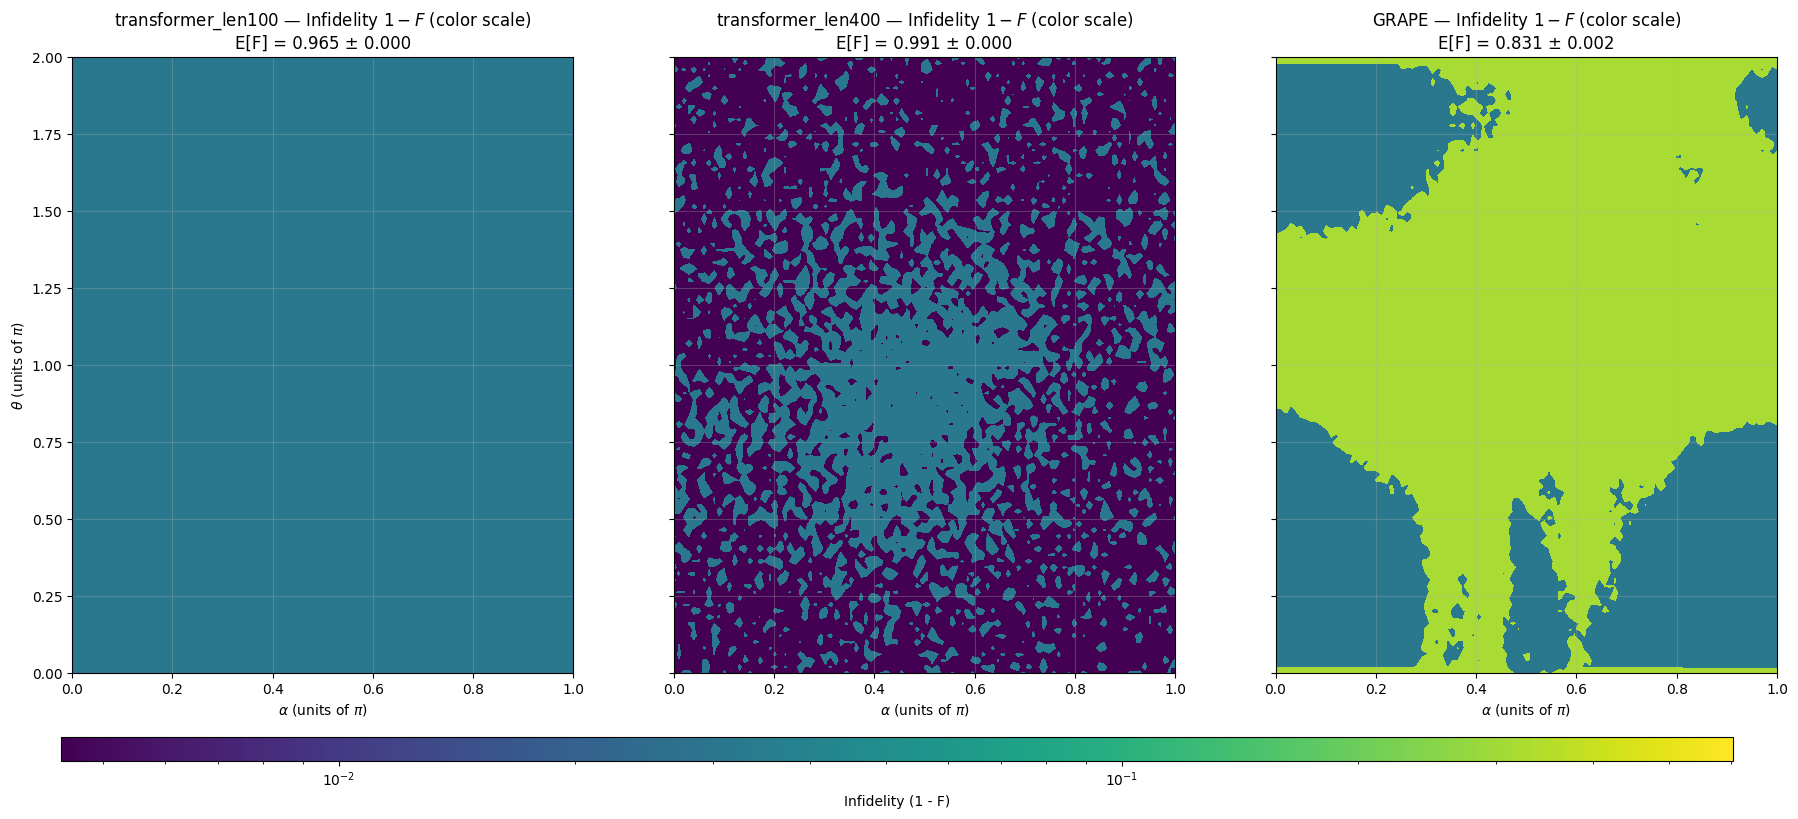

In [4]:
# ---------------------- Plot: 1×3 row, shared colorbar ----------------------
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(22, 8), sharex=True, sharey=True)
if not isinstance(axes, (list, np.ndarray)):
    axes = [axes]

for ax, r in zip(axes, results):
    # NOTE: we pass raw infidelity and use LogNorm; this is equivalent to plotting log(1-F)
    cf = ax.contourf(alpha_np, theta_np, r["I_np"], levels=levels, cmap=cmap, norm=log_norm)
    ax.grid(True, alpha=0.3)
    ax.set_title(
        rf"{r['name']} — Infidelity $1-F$ (color scale)"
        + f"\nE[F] = {r['weighted_avg']:.3f} ± {r['weighted_se']:.3f}"
    )

axes[0].set_ylabel(r"$\theta$ (units of $\pi$)")
for ax in axes:
    ax.set_xlabel(r"$\alpha$ (units of $\pi$)")




# after plotting
sm = cm.ScalarMappable(norm=log_norm, cmap=cmap); sm.set_array([])

# [left, bottom, width, height] in figure coords
cax = fig.add_axes([0.12, 0.0, 0.76, 0.03])
cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
cbar.set_label("Infidelity (1 - F)")
# cbar.formatter = mticker.FuncFormatter(lambda x, pos: f"{x:g}")
cbar.update_ticks()

plt.show()



In [4]:
# model_option = "100 length"
# model_option = "400 length"
model_option = "GRAPE"

if model_option == "100 length":
    name = "transformer_len100"
    path = "demo_universal/weight/length_100.pt"
    params = load_model_params("demo_universal/params/length_100.json")
elif model_option == "400 length":
    name = "transformer_len400"
    path = "demo_universal/weight/length_400.pt"
    params = load_model_params("demo_universal/params/length_400.json")
else: # GRAPE
    name = "GRAPE"
    path = "demo_universal/weight/grape.pt"
    params = load_model_params("demo_universal/params/grape.json")

if model_option in ["100 length", "400 length"]:

    pipeline = Pipeline(
        UniversalQOCTransformer(**params),
        weight_path=path,
        device="cpu"
    )

else: # GRAPE
    pipeline = GRAPE(**params)
    pipeline.load_state_dict(torch.load(path))
    pipeline.eval()


from scipy.linalg import expm


_I2_CPU = torch.eye(2, dtype=torch.cfloat)
_SIGMA_X_CPU = torch.tensor([[0.0, 1.0], [1.0, 0.0]], dtype=torch.cfloat)
_SIGMA_Y_CPU = torch.tensor([[0.0, -1.0j], [1.0j, 0.0]], dtype=torch.cfloat)
_SIGMA_Z_CPU = torch.tensor([[1.0, 0.0], [0.0, -1.0]], dtype=torch.cfloat)
pauli = [_I2_CPU, _SIGMA_X_CPU, _SIGMA_Y_CPU, _SIGMA_Z_CPU]

def euler_yxy_from_axis_angle(nx, ny, nz, theta, *, eps=1e-12):
    """
    Return Euler angles (alpha, beta, gamma) for the y‑x‑y sequence so that
        R_y(alpha) R_x(beta) R_y(gamma)
    equals a rotation of angle `theta` about the axis (nx, ny, nz).

    Handles every special case: θ≈0, θ≈π, axis along ±y, axis in x‑z plane.
    """
    # ---- normalise the axis ------------------------------------------------
    n = np.array([nx, ny, nz], dtype=float)
    n /= np.linalg.norm(n)
    nx, ny, nz = n

    # ---- useful trig shorthands -------------------------------------------
    c = np.cos(theta)          # cos θ
    s = np.sin(theta)          # sin θ
    k = 1.0 - c                # = 2 sin²(θ/2)

    # ---- middle angle β ----------------------------------------------------
    cos_beta = np.clip(c + k * ny * ny, -1.0, 1.0)
    beta     = np.arccos(cos_beta)
    sin_beta = np.sin(beta)

    # -----------------------------------------------------------------------
    # 1) Generic case  (sin β not tiny)  →  use the closed‑form directly
    # -----------------------------------------------------------------------
    if abs(sin_beta) > eps:
        alpha = np.arctan2(k * nx * ny - s * nz,
                           k * ny * nz + s * nx)
        gamma = np.arctan2(k * nx * ny + s * nz,
                           s * nx       - k * ny * nz)
        return alpha, beta, gamma

    # -----------------------------------------------------------------------
    # 2) Singular cases  (sin β ≈ 0)  →  β is 0 or π
    # -----------------------------------------------------------------------
    if abs(ny) > 1 - eps:          # axis almost parallel to ±y
        # Rotation sits entirely on the y‑axis
        alpha = 0.0
        beta  = 0.0
        gamma = +theta if ny > 0 else -theta
        return alpha, beta, gamma

    # Remaining possibility:  ny ≈ 0  and  β ≈ π  (axis in x‑z plane,
    # half‑turn).  Keep α = 0 and solve γ from the x–z block.
    alpha = 0.0
    beta  = np.pi
    gamma = np.arctan2(k * nx * nz,          #  2 nx nz   when θ = π
                       c + k * nx * nx)      # -1+2 nx²   when θ = π
    return alpha, beta, gamma


def Rx(theta):
    return expm(-1j * _SIGMA_X_CPU * theta / 2)

def Ry(theta):
    return expm(-1j * _SIGMA_Y_CPU * theta / 2)


def _rotation_unitary(axis, theta) -> torch.Tensor:
    """Generate a Haar‑random SU(2) element via axis‑angle rotation."""
    # normalize
    if type(axis) is tuple:
        axis = torch.tensor(axis, dtype=torch.float64)
    axis /= axis.norm()
    n_x, n_y, n_z = axis
    H = 0.5 * theta * (n_x * _SIGMA_X_CPU + n_y * _SIGMA_Y_CPU + n_z * _SIGMA_Z_CPU)
    return torch.matrix_exp(-1j * H)


def get_total_pulse(axis, theta):

    n_x, n_y, n_z = axis

    pulse = pipeline(torch.tensor([n_x, n_y, n_z, theta], dtype=torch.float32).unsqueeze(0)).squeeze(0).detach()

    return pulse


def avg_fidelity(U_target, pulse, M=10000):
    errors_mc = get_ore_ple_error_distribution(M, 1, 0.05)
    U_target_plot = torch.stack([U_target]).repeat_interleave(M, dim=0)
    pulses_plot = torch.stack([pulse]).repeat_interleave(M, dim=0)

    U_out_plot = batched_unitary_generator(pulses_plot, errors_mc)
    F = fidelity(U_out_plot, U_target_plot, 1)

    F_mean = F.mean().item()
    return F_mean

def get_unitary(alpha, theta):
    H = math.cos(alpha) * _SIGMA_Z_CPU + math.sin(alpha) * _SIGMA_X_CPU
    return torch.linalg.matrix_exp(-1j * H * theta / 2)



alpha_vals = torch.linspace(0, math.pi, 100)
theta_vals = torch.linspace(0, 2*math.pi, 100)
# alpha_grid, theta_grid = torch.meshgrid(alpha_vals, theta_vals, indexing="ij")

F_grid = []

print("calculating fidelities")

for alpha in tqdm(alpha_vals):
    for theta in theta_vals:
        F_grid.append(
            avg_fidelity(
                get_unitary(alpha, theta), 
                get_total_pulse((math.sin(alpha), 0, math.cos(alpha)), theta)
            )
        )


F_grid_tensor = torch.tensor(F_grid).reshape(100, 100)

alpha_grid, theta_grid = torch.meshgrid(alpha_vals, theta_vals, indexing="ij")

alpha_np = alpha_grid.detach().cpu().numpy() / np.pi
theta_np = theta_grid.detach().cpu().numpy() / np.pi
F_np = F_grid_tensor.numpy()

weights = (theta_grid ** 2) * torch.sin(alpha_grid)


plt.figure(figsize=(8, 6))
# contour = plt.contourf(alpha_np, theta_np, F_np, levels=[0.8, 0.88, 0.9, 0.92, 0.94, 0.96, 0.98, 1.0], cmap='viridis')
contour = plt.contourf(alpha_np, theta_np, F_np, cmap='viridis')


plt.colorbar(contour, label='Fidelity')
plt.xlabel(r"$\alpha$ (units of $\pi$)")
plt.ylabel(r"$\theta$ (units of $\pi)$")

weights_np = weights.detach().cpu().numpy()

weighted_avg = (F_np * weights_np).sum() / weights_np.sum()
# Weighted variance
weighted_var = ((weights_np * (F_np - weighted_avg)**2).sum()) / weights_np.sum()

# Effective sample size
N_eff = (weights_np.sum())**2 / (weights_np**2).sum()

# Weighted standard error
weighted_se = np.sqrt(weighted_var) / np.sqrt(N_eff)

title_str = (
    r"Fidelity plot of axis = $(\sin\alpha, 0, \cos\alpha)$, rotation = $\theta$"
    f"\nE[F] = {weighted_avg:.3f} +/- {weighted_se:.3f}"
)
plt.title(title_str)
plt.grid(True)


calculating fidelities


  1%|          | 1/100 [01:09<1:55:12, 69.83s/it]


KeyboardInterrupt: 

In [16]:
alpha_vals = torch.linspace(0, math.pi, 100)
theta_vals = torch.linspace(0, 2*math.pi, 100)
# alpha_grid, theta_grid = torch.meshgrid(alpha_vals, theta_vals, indexing="ij")

F_grid = []

print("calculating fidelities")

for alpha in tqdm(alpha_vals):
    for theta in theta_vals:
        F_grid.append(
            avg_fidelity(
                get_unitary(alpha, theta), 
                get_total_pulse((math.sin(alpha), 0, math.cos(alpha)), theta)
            )
        )

calculating fidelities


100%|██████████| 100/100 [1:12:42<00:00, 43.63s/it]


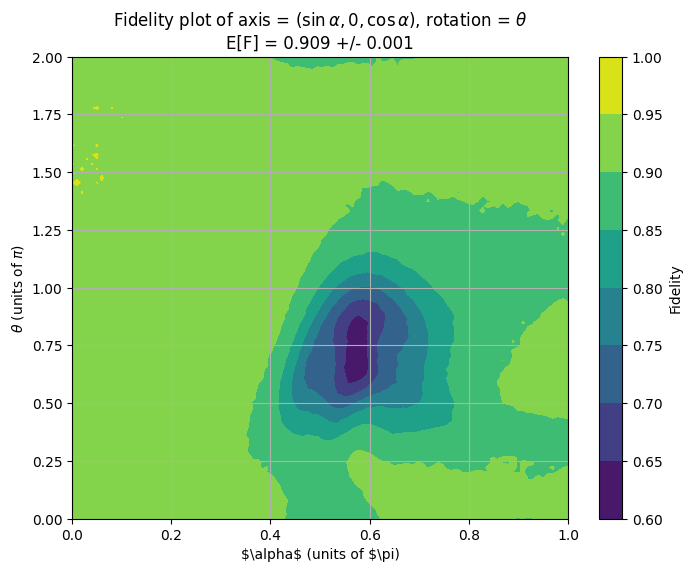

calculating fidelities


100%|██████████| 100/100 [47:46<00:00, 28.66s/it]  


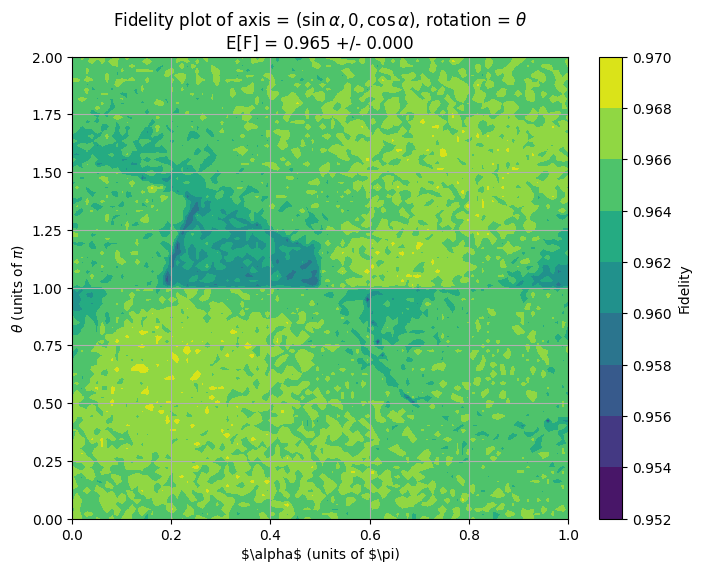

In [19]:
model_option = "100 length"
# model_option = "400 length"
# model_option = "GRAPE"

if model_option == "100 length":
    name = "transformer_len100"
    path = "demo_universal/weight/length_100.pt"
    params = load_model_params("demo_universal/params/length_100.json")
elif model_option == "400 length":
    name = "transformer_len400"
    path = "demo_universal/weight/length_400.pt"
    params = load_model_params("demo_universal/params/length_400.json")
else: # GRAPE
    name = "GRAPE"
    path = "demo_universal/weight/grape.pt"
    params = load_model_params("demo_universal/params/grape.json")

if model_option in ["100 length", "400 length"]:

    pipeline = Pipeline(
        UniversalQOCTransformer(**params),
        weight_path=path,
        device="cpu"
    )

else: # GRAPE
    pipeline = GRAPE(**params)
    pipeline.load_state_dict(torch.load(path))
    pipeline.eval()




alpha_vals = torch.linspace(0, math.pi, 100)
theta_vals = torch.linspace(0, 2*math.pi, 100)
# alpha_grid, theta_grid = torch.meshgrid(alpha_vals, theta_vals, indexing="ij")

F_grid = []

print("calculating fidelities")

for alpha in tqdm(alpha_vals):
    for theta in theta_vals:
        F_grid.append(
            avg_fidelity(
                get_unitary(alpha, theta), 
                get_total_pulse((math.sin(alpha), 0, math.cos(alpha)), theta)
            )
        )


F_grid_tensor = torch.tensor(F_grid).reshape(100, 100)

alpha_grid, theta_grid = torch.meshgrid(alpha_vals, theta_vals, indexing="ij")

alpha_np = alpha_grid.detach().cpu().numpy() / np.pi
theta_np = theta_grid.detach().cpu().numpy() / np.pi
F_np = F_grid_tensor.numpy()

plt.figure(figsize=(8, 6))
# contour = plt.contourf(alpha_np, theta_np, F_np, levels=[0.8, 0.88, 0.9, 0.92, 0.94, 0.96, 0.98, 1.0], cmap='viridis')
contour = plt.contourf(alpha_np, theta_np, F_np, cmap='viridis')


plt.colorbar(contour, label='Fidelity')
plt.xlabel(r"$\alpha$ (units of $\pi)")
plt.ylabel(r"$\theta$ (units of $\pi)$")
weights_np = weights.detach().cpu().numpy()

weighted_avg = (F_np * weights_np).sum() / weights_np.sum()
# Weighted variance
weighted_var = ((weights_np * (F_np - weighted_avg)**2).sum()) / weights_np.sum()

# Effective sample size
N_eff = (weights_np.sum())**2 / (weights_np**2).sum()

# Weighted standard error
weighted_se = np.sqrt(weighted_var) / np.sqrt(N_eff)

title_str = (
    r"Fidelity plot of axis = $(\sin\alpha, 0, \cos\alpha)$, rotation = $\theta$"
    f"\nE[F] = {weighted_avg:.3f} +/- {weighted_se:.3f}"
)
plt.title(title_str)
plt.grid(True)


In [34]:
alpha_grid.shape, theta_grid.shape

(torch.Size([100, 100]), torch.Size([100, 100]))

In [33]:
for alpha, theta in tqdm(zip(alpha_grid, theta_grid)):
    print(alpha)
    print(theta)
    break


0it [00:00, ?it/s]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.])
tensor([0.0000, 0.0635, 0.1269, 0.1904, 0.2539, 0.3173, 0.3808, 0.4443, 0.5077,
        0.5712, 0.6347, 0.6981, 0.7616, 0.8251, 0.8885, 0.9520, 1.0155, 1.0789,
        1.1424, 1.2059, 1.2693, 1.3328, 1.3963, 1.4597, 1.5232, 1.5867, 1.6501,
        1.7136, 1.7771, 1.8405, 1.9040, 1.9675, 2.0309, 2.0944, 2.1579, 2.2213,
        2.2848, 2.3483, 2.4117, 2.4752, 2.5387, 2.6021, 2.6656, 2.7291, 2.7925,
        2.8560, 2.9195, 2.9829, 3.0464, 3.1099, 3.1733, 3.2368, 3.3003, 3.3637,
        3.4272, 3.4907, 3.5541, 3.6176, 3.6811, 3.7445, 3.8080, 3.8715, 3.9349,

In [ ]:
import pandas as pd

s = pd.Series(F_list)

s.to_csv("Fidelity_list.csv")

In [7]:
from tqdm import tqdm

M = 1000
theta_list = torch.arange(1/M, 1 + 1/M, 1/M)
F_list = []
F_err_list = []

for theta in tqdm(theta_list):
    SCORE_tensor, U_target = get_score_emb_unitary(0, theta * math.pi)
    pulse = model(SCORE_tensor.unsqueeze(0)).squeeze(0).detach()
    errors_mc = get_ore_ple_error_distribution(M, 1, 0.05)
    U_target_plot = torch.stack([U_target]).repeat_interleave(M, dim=0)
    pulses_plot = torch.stack([pulse]).repeat_interleave(M, dim=0)
    U_out_plot = batched_unitary_generator(pulses_plot, errors_mc)
    F = fidelity(U_out_plot, U_target_plot, 1)

    F_mean = F.mean().item()
    F_err = F.std().item() / np.sqrt(M)
    F_list.append(F_mean)
    F_err_list.append(F_err)

100%|██████████| 1000/1000 [00:30<00:00, 33.14it/s]


Text(0.5, 1.0, 'Average Fidelity of composite_pulse_len100 \nfor $R_x(\\theta)$: 0.955')

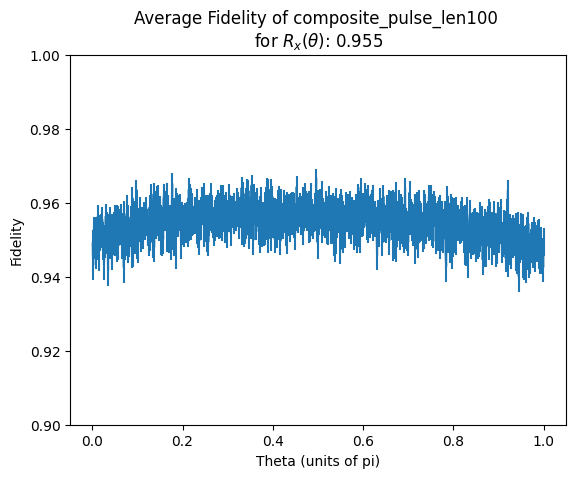

In [8]:
import matplotlib.pyplot as plt

plt.errorbar(theta_list, F_list, F_err_list)
plt.ylim(0.9, 1)
plt.xlabel("Theta (units of pi)")
plt.ylabel("Fidelity")
title = (
    f"Average Fidelity of {model_name} \n"
    fr"for $R_x(\theta)$: {np.mean(F_list):.3f}"
)
plt.title(title)

In [42]:
import torch
import numpy as np

def decompose_XYX(U: torch.Tensor):
    """
    Decompose a 2x2 SU(2) matrix U into U = R_x(alpha) R_y(beta) R_x(gamma)
    Returns: tensor([alpha, beta, gamma]) (dtype=torch.double)
    """
    U = U.to(torch.cdouble)

    # Remove global phase: det(U) = 1
    phase = torch.angle(torch.det(U)) / 2
    U = U * torch.exp(-1j * phase)

    u00, u01 = U[0,0], U[0,1]

    # Beta (clamped)
    beta = 2 * torch.acos(torch.clamp(torch.abs(u00), -1.0, 1.0))

    eps = 1e-8
    zero = torch.tensor(0.0, dtype=torch.double)
    pi = torch.tensor(np.pi, dtype=torch.double)

    if torch.isclose(beta, zero, atol=eps):
        alpha = torch.tensor(0.0, dtype=torch.double)
        gamma = -2 * torch.angle(u01)
    elif torch.isclose(beta, pi, atol=eps):
        alpha = -2 * torch.angle(u01)
        gamma = torch.tensor(0.0, dtype=torch.double)
    else:
        sum_ag = -2 * torch.angle(u00)
        diff_ag = -2 * torch.angle(-1j * u01)

        alpha = 0.5 * (sum_ag + diff_ag)
        gamma = 0.5 * (sum_ag - diff_ag)

    return torch.stack([alpha.real, beta.real, gamma.real])


In [43]:
U_target = torch.tensor([[1, 1],
                         [1, -1]], dtype=torch.cfloat) / np.sqrt(2)

angles = decompose_XYX(U_target)
print("alpha, beta, gamma =", angles)


alpha, beta, gamma = tensor([ 4.7124,  1.5708, -1.5708], dtype=torch.float64)


In [44]:
import torch
import numpy as np

# Define Rx, Ry
def Rx(theta):
    X = torch.tensor([[0, 1], [1, 0]], dtype=torch.cdouble)
    return torch.matrix_exp(-1j * theta / 2 * X)

def Ry(theta):
    Y = torch.tensor([[0, -1j], [1j, 0]], dtype=torch.cdouble)
    return torch.matrix_exp(-1j * theta / 2 * Y)

def reconstruct(alpha, beta, gamma):
    return Rx(alpha) @ Ry(beta) @ Rx(gamma)

def equal_up_to_global_phase(U1, U2, atol=1e-8):
    # Normalize determinants
    U1n = U1 / torch.det(U1).sqrt()
    U2n = U2 / torch.det(U2).sqrt()
    return torch.allclose(U1n, U2n, atol=atol)

# Import the function from previous code
# from your_code import decompose_XYX

# ========================
# TEST CASES
# ========================

def test_decompose_XYX():
    # 1. Hadamard
    H = torch.tensor([[1, 1], [1, -1]], dtype=torch.cdouble) / np.sqrt(2)
    a, b, c = decompose_XYX(H)
    U_rec = reconstruct(a, b, c)
    print("Hadamard angles:", a, b, c)
    print(H, U_rec)
    assert equal_up_to_global_phase(H, U_rec)

    # 2. Resonant rotations along x and y axis
    for angle in [np.pi/3, np.pi/2, np.pi]:
        Ux = Rx(angle)
        Uy = Ry(angle)
        ax, bx, cx = decompose_XYX(Ux)
        ay, by, cy = decompose_XYX(Uy)
        assert equal_up_to_global_phase(Ux, reconstruct(ax, bx, cx))
        assert equal_up_to_global_phase(Uy, reconstruct(ay, by, cy))
    print("Resonant rotations along x, y passed")

    # 3. Rotations along x-y plane not aligned with x or y (e.g. 45° in plane)
    theta = np.pi/2
    n = (1/np.sqrt(2)) * (Rx(theta) @ Ry(0))  # axis at 45 degrees in x-y plane
    U_xy = torch.matrix_exp(-1j * theta/2 * (torch.tensor([[0,1],[1,0]]) + torch.tensor([[0,-1j],[1j,0]])) / np.sqrt(2))
    a, b, c = decompose_XYX(U_xy)
    assert equal_up_to_global_phase(U_xy, reconstruct(a, b, c))
    print("Rotations along x-y plane passed")

    # 4. Z-rotations (not directly Rx or Ry)
    # Use Euler identity: Rz(theta) = Rx(pi/2) Ry(theta) Rx(-pi/2)
    for angle in [np.pi/4, np.pi/2, np.pi]:
        Rz = Rx(np.pi/2) @ Ry(angle) @ Rx(-np.pi/2)
        a, b, c = decompose_XYX(Rz)
        assert equal_up_to_global_phase(Rz, reconstruct(a, b, c))
    print("Z-rotations passed")

    # 5. Random SU(2) rotations
    for _ in range(10):
        # Random axis and angle
        axis = torch.randn(3)
        axis = axis / torch.norm(axis)
        theta = np.pi * torch.rand(1).item()
        # Build U = exp(-i axis·sigma * theta/2)
        X = torch.tensor([[0, 1], [1, 0]], dtype=torch.cdouble)
        Y = torch.tensor([[0, -1j], [1j, 0]], dtype=torch.cdouble)
        Z = torch.tensor([[1, 0], [0, -1]], dtype=torch.cdouble)
        H = axis[0]*X + axis[1]*Y + axis[2]*Z
        U_rand = torch.matrix_exp(-1j * theta / 2 * H)

        a, b, c = decompose_XYX(U_rand)
        assert equal_up_to_global_phase(U_rand, reconstruct(a, b, c))
    print("Random SU(2) rotations passed")

    print("All tests passed!")

# Run the tests
test_decompose_XYX()


Hadamard angles: tensor(4.7124, dtype=torch.float64) tensor(1.5708, dtype=torch.float64) tensor(-1.5708, dtype=torch.float64)
tensor([[ 0.7071+0.j,  0.7071+0.j],
        [ 0.7071+0.j, -0.7071+0.j]], dtype=torch.complex128) tensor([[ 2.7756e-16-6.6613e-16j,  7.0711e-01-7.0711e-01j],
        [-7.0711e-01-7.0711e-01j,  2.7756e-16+6.6613e-16j]],
       dtype=torch.complex128)


AssertionError: 

In [ ]:
model = CompositePulseTransformerEncoder(**model_params)

In [ ]:
def fidelity(theta, phi):
    theta = math.pi * np.round(theta/math.pi, 3)

    

    # load pretrained module

    model.load_state_dict(torch.load(model_path))
    model.eval()

    _, U_target = get_score_emb_unitary(phi, theta)
    SCORE_tensor_base, _ = get_score_emb_unitary(0, theta)

    pulse = model(SCORE_tensor_base.unsqueeze(0)).squeeze(0).detach()

    pulse[:, 0] += phi
    return pulse